# 🏨 HOTEL BOOKING CANCELLATION PREDICTION USING MACHINE LEARNING
📘 Course:
MIS 444 – Predictive Analytics in Business

Problem Type:
Classification Problem

👨‍🎓 Student Name: Fabiha Bushra Ali

👨‍🏫 Instructor: Najmul Hasan

📂 Dataset Source:
Kaggle – (https://https://www.kaggle.com/code/mohamedzayton/hotel-booking)

🛠 Tools & Technologies Used:
Python, Google Colab, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn

# **Project Outline**

1. Data Collection
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Selection
5. Model Building
6. Model Optimization
7. Model Evaluation & Validation




# 1. Data Collection
The dataset used in this project was collected from Kaggle, a popular online platform for data science and machine learning projects. The dataset is known as the Hotel Booking Demand Dataset and contains hotel reservation information for both resort and city hotels.



In [24]:
#importing necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

file_path = r"/content/hotel_booking.csv"
df = pd.read_csv (file_path)
df



,hotel,is_canceled,lead_time,reservation_status_date,stays_in_weekend,stays_in_week,adults,children,babies,meal,...,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,reserved_room_type,booking_changes,customer_type,adr,required_car_parking_spaces,reservation_status
0,Resort Hotel,0,342,7/1/2015,0,0,2,0.0,0,BB,...,Direct,Direct,0,0,C,3,Transient,0.00,0,Check-Out
1,Resort Hotel,0,737,7/1/2015,0,0,2,0.0,0,BB,...,Direct,Direct,0,0,C,4,Transient,0.00,0,Check-Out
2,Resort Hotel,0,7,7/2/2015,0,1,1,0.0,0,BB,...,Direct,Direct,0,0,A,0,Transient,75.00,0,Check-Out
3,Resort Hotel,0,13,7/2/2015,0,1,1,0.0,0,BB,...,Corporate,Corporate,0,0,A,0,Transient,75.00,0,Check-Out
4,Resort Hotel,0,14,7/3/2015,0,2,2,0.0,0,BB,...,Online TA,TA/TO,0,0,A,0,Transient,98.00,0,Check-Out
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,9/6/2017,2,5,2,0.0,0,BB,...,Offline TA/TO,TA/TO,0,0,A,0,Transient,96.14,0,Check-Out
119386,City Hotel,0,102,9/7/2017,2,5,3,0.0,0,BB,...,Online TA,TA/TO,0,0,E,0,Transient,225.43,0,Check-Out
119387,City Hotel,0,34,9/7/2017,2,5,2,0.0,0,BB,...,Online TA,TA/TO,0,0,D,0,Transient,157.71,0,Check-Out
119388,City Hotel,0,109,9/7/2017,2,5,2,0.0,0,BB,...,Online TA,TA/TO,0,0,A,0,Transient,104.40,0,Check-Out


# 2. Data Preprocessing
-Handling missing values

-Removing duplicate records

-Removing data leakage columns

-Outlier detection and capping

-Separating numerical and categorical variables

-One-hot encoding categorical variables

-Train-test split for model evaluation

-Data cleaning and transformation for machine learning readiness

In [10]:
# Step 2.1: Checking for missing values
print("=== Missing Values Per Column ===")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== Missing Values Per Column ===
hotel                            0
is_canceled                      0
lead_time                        0
reservation_status_date          0
stays_in_weekend                 0
stays_in_week                    0
adults                           0
children                         4
babies                           0
meal                             0
country                        488
market_segment                   0
distribution_channel             0
is_repeated_guest                0
previous_cancellations           0
reserved_room_type               0
booking_changes                  0
customer_type                    0
adr                              0
required_car_parking_spaces      0
reservation_status               0
dtype: int64

Total missing values: 492


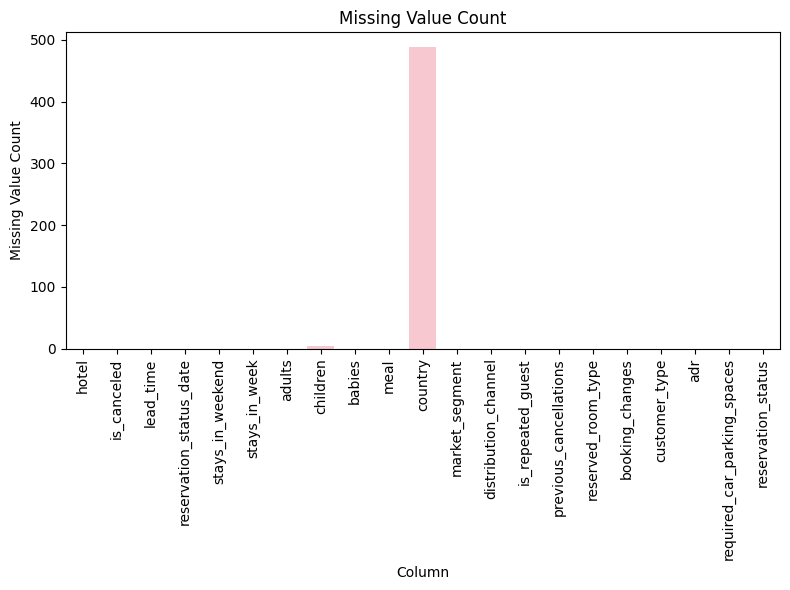

In [11]:
#Step 2.2: Visualize missing values

missing = df.isnull().sum()
plt.figure(figsize=(8, 6))
sns.barplot(x=missing.index, y=missing.values, color='pink')
plt.title('Missing Value Count', fontsize=12)
plt.xlabel('Column')
plt.ylabel('Missing Value Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

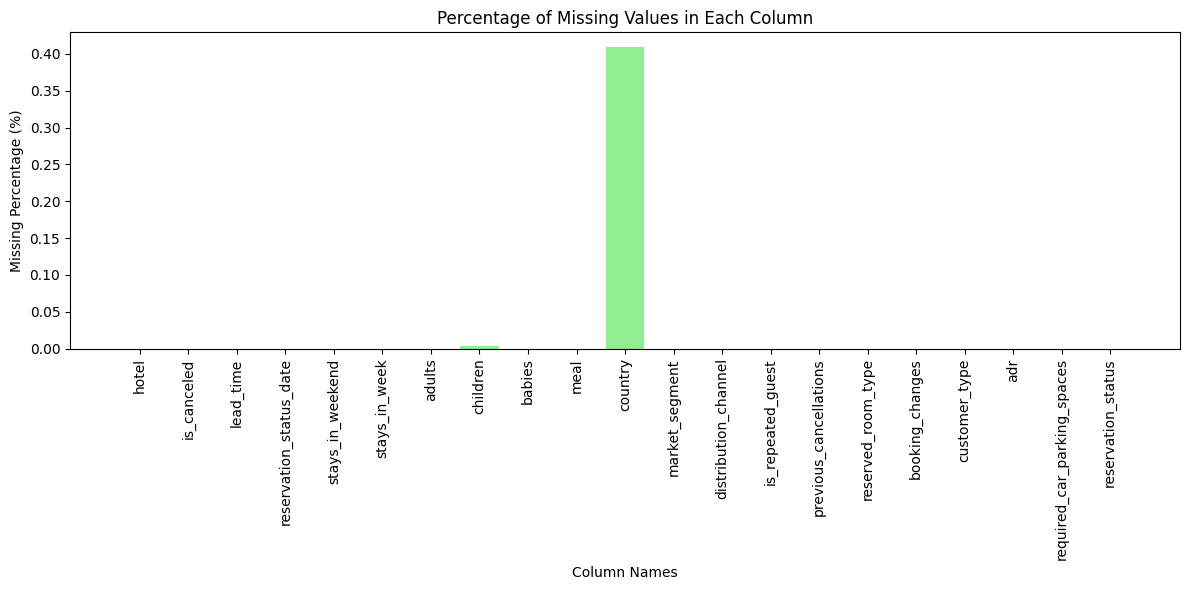

In [12]:
# Step 2.3: Visualize the percentage of missing values

missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100

plt.figure(figsize=(12, 6))
plt.bar(missing_percentage.index, missing_percentage.values, color='lightgreen')
plt.title('Percentage of Missing Values in Each Column', fontsize=12)
plt.xlabel('Column Names')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [13]:
#2.4 Dropping irrelevant or missing valued columns

missing_threshold = 50

# Drop columns with missing values above the threshold
columns_to_drop = missing_percentage[missing_percentage > missing_threshold].index
df = df.drop(columns=columns_to_drop)
irrelevant_columns = ['country', 'required_car_parking_spaces']

print("Data after dropping missing and irrelevant columns:")
print(df.shape)
print(df.columns)


Data after dropping missing and irrelevant columns:
(119390, 21)
Index(['hotel', 'is_canceled', 'lead_time', 'reservation_status_date',
       'stays_in_weekend', 'stays_in_week', 'adults', 'children', 'babies',
       'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations', 'reserved_room_type',
       'booking_changes', 'customer_type', 'adr',
       'required_car_parking_spaces', 'reservation_status'],
      dtype='object')


In [14]:
#2.5 Check and remove duplicate rows
duplicates = df[df.duplicated()]
print(f"Duplicate rows found: {duplicates}")

df = df.drop_duplicates()

print("Data after removing duplicate rows:")
print(df.shape)
print(df.head(5))

Duplicate rows found:                hotel  is_canceled  lead_time reservation_status_date  \
5       Resort Hotel            0         14                7/3/2015   
22      Resort Hotel            0         72                7/7/2015   
43      Resort Hotel            0         70                7/7/2015   
130     Resort Hotel            0        100                7/6/2015   
138     Resort Hotel            1          5                7/1/2015   
...              ...          ...        ...                     ...   
119349    City Hotel            0        186                9/3/2017   
119352    City Hotel            0         63                9/3/2017   
119353    City Hotel            0         63                9/3/2017   
119354    City Hotel            0         63                9/3/2017   
119373    City Hotel            0        175                9/4/2017   

        stays_in_weekend  stays_in_week  adults  children  babies meal  ...  \
5                      0          

In [45]:
#2.6 Impute missing values
from sklearn.impute import SimpleImputer

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

numerical_imputer = SimpleImputer(strategy='mean')
df[numerical_columns] = numerical_imputer.fit_transform(df[numerical_columns])

categorical_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_columns] = categorical_imputer.fit_transform(df[categorical_columns])

print("Data after imputing missing values:")
print(df.isnull().sum())

Data after imputing missing values:
hotel                          0
is_canceled                    0
lead_time                      0
stays_in_weekend               0
stays_in_week                  0
adults                         0
children                       0
babies                         0
meal                           0
country                        0
market_segment                 0
distribution_channel           0
is_repeated_guest              0
previous_cancellations         0
reserved_room_type             0
booking_changes                0
customer_type                  0
adr                            0
required_car_parking_spaces    0
dtype: int64


In [46]:
#2.7 Remove data leakage/irrelavent columns
#these columns reveal the final result, so we must remove them.

leakage_cols = ["reservation_status", "reservation_status_date", "country"]

df = df.drop(columns=[col for col in leakage_cols if col in df.columns])

print("Remaining columns:")
print(df.columns)


Remaining columns:
Index(['hotel', 'is_canceled', 'lead_time', 'stays_in_weekend',
       'stays_in_week', 'adults', 'children', 'babies', 'meal',
       'market_segment', 'distribution_channel', 'is_repeated_guest',
       'previous_cancellations', 'reserved_room_type', 'booking_changes',
       'customer_type', 'adr', 'required_car_parking_spaces'],
      dtype='object')


In [47]:
#2.8 Detecting negative/ invalid values

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_columns:
   df[col] = df[col].apply(lambda x: 0 if x < 0 else x)
print("Data after replacing negative values with 0 for each column:")
print(df[numerical_columns].head(5))



Data after replacing negative values with 0 for each column:
   is_canceled  lead_time  stays_in_weekend  stays_in_week  adults  children  \
0          0.0      342.0               0.0            0.0     2.0       0.0   
1          0.0      373.0               0.0            0.0     2.0       0.0   
2          0.0        7.0               0.0            1.0     2.0       0.0   
3          0.0       13.0               0.0            1.0     2.0       0.0   
4          0.0       14.0               0.0            2.0     2.0       0.0   

   babies  is_repeated_guest  previous_cancellations  booking_changes   adr  \
0     0.0                0.0                     0.0              0.0   0.0   
1     0.0                0.0                     0.0              0.0   0.0   
2     0.0                0.0                     0.0              0.0  75.0   
3     0.0                0.0                     0.0              0.0  75.0   
4     0.0                0.0                     0.0           

In [48]:
#2.8 Outlier detection and capping using the IQR method

print("=== Outlier Detection & Capping (IQR Method) ===")

numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
columns_to_check = numerical_columns
for col in columns_to_check:

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  before = ((df[col] < lower) | (df[col] > upper)).sum()
  df[col] = df[col].clip(lower=lower, upper=upper)
  after = ((df[col] < lower) | (df[col] > upper)).sum()

  print(f"{col:20s} → {before} outliers found, capped to [{lower}, {upper}]")
print(f"\nTotal rows after capping: {df.shape[0]} (no rows dropped)")


=== Outlier Detection & Capping (IQR Method) ===
is_canceled          → 0 outliers found, capped to [-1.5, 2.5]
lead_time            → 0 outliers found, capped to [-195.0, 373.0]
stays_in_weekend     → 0 outliers found, capped to [-3.0, 5.0]
stays_in_week        → 0 outliers found, capped to [-2.0, 6.0]
adults               → 0 outliers found, capped to [2.0, 2.0]
children             → 0 outliers found, capped to [0.0, 0.0]
babies               → 0 outliers found, capped to [0.0, 0.0]
is_repeated_guest    → 0 outliers found, capped to [0.0, 0.0]
previous_cancellations → 0 outliers found, capped to [0.0, 0.0]
booking_changes      → 0 outliers found, capped to [0.0, 0.0]
adr                  → 0 outliers found, capped to [-15.774999999999991, 211.065]
required_car_parking_spaces → 0 outliers found, capped to [0.0, 0.0]

Total rows after capping: 119390 (no rows dropped)


Insight:

Outliers were detected in numerical variables and capped to reduce the effect of extreme values. This helps prevent the model from being overly influenced by unusual observations and improves model stability.

In [49]:
#2.9 Encoding categorical variables (One-Hot encoding)
print("Shape before encoding:", df.shape)

categorical_cols = df.select_dtypes(include=["object"]).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)

df_encoded.head(5)


Shape before encoding: (119390, 18)
Shape after encoding: (119390, 40)


,is_canceled,lead_time,stays_in_weekend,stays_in_week,adults,children,babies,is_repeated_guest,previous_cancellations,booking_changes,...,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0.0,342.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,0.0,373.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,0.0,7.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
3,0.0,13.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,0.0,14.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False


Insight: One-hot encoding was applied to convert categorical variables into numerical form.

In [50]:
# 2.10 Split the dataset into features (X) and target (y)
from sklearn.model_selection import train_test_split

X_raw = df_encoded.drop('is_canceled', axis=1) # Features
y = df_encoded['is_canceled'].values # Target

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train_raw.shape}")
print(f"X_test shape: {X_test_raw.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (83573, 39)
X_test shape: (35817, 39)
y_train shape: (83573,)
y_test shape: (35817,)


Insight: The dataset was split into training and testing sets. The training set was used to train the models, while the testing set was used to evaluate performance on unseen data


# 3. Exploratory Data Analysis  (EDA)

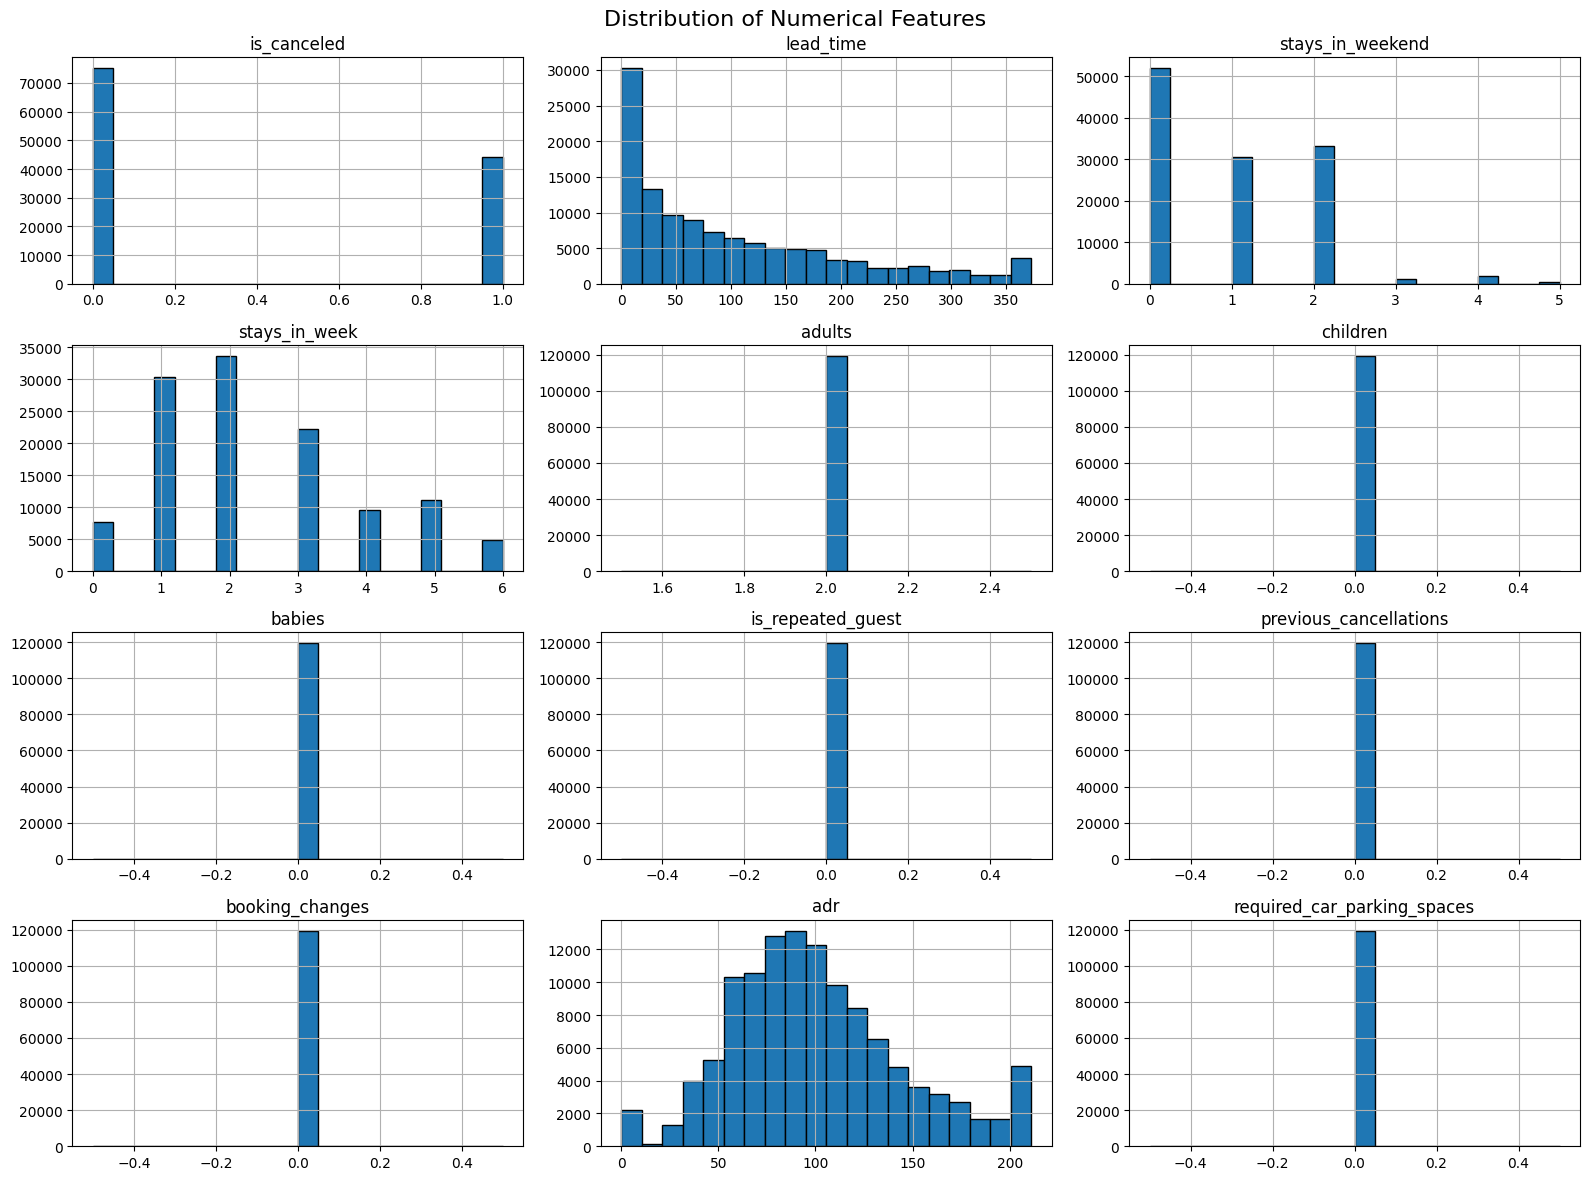

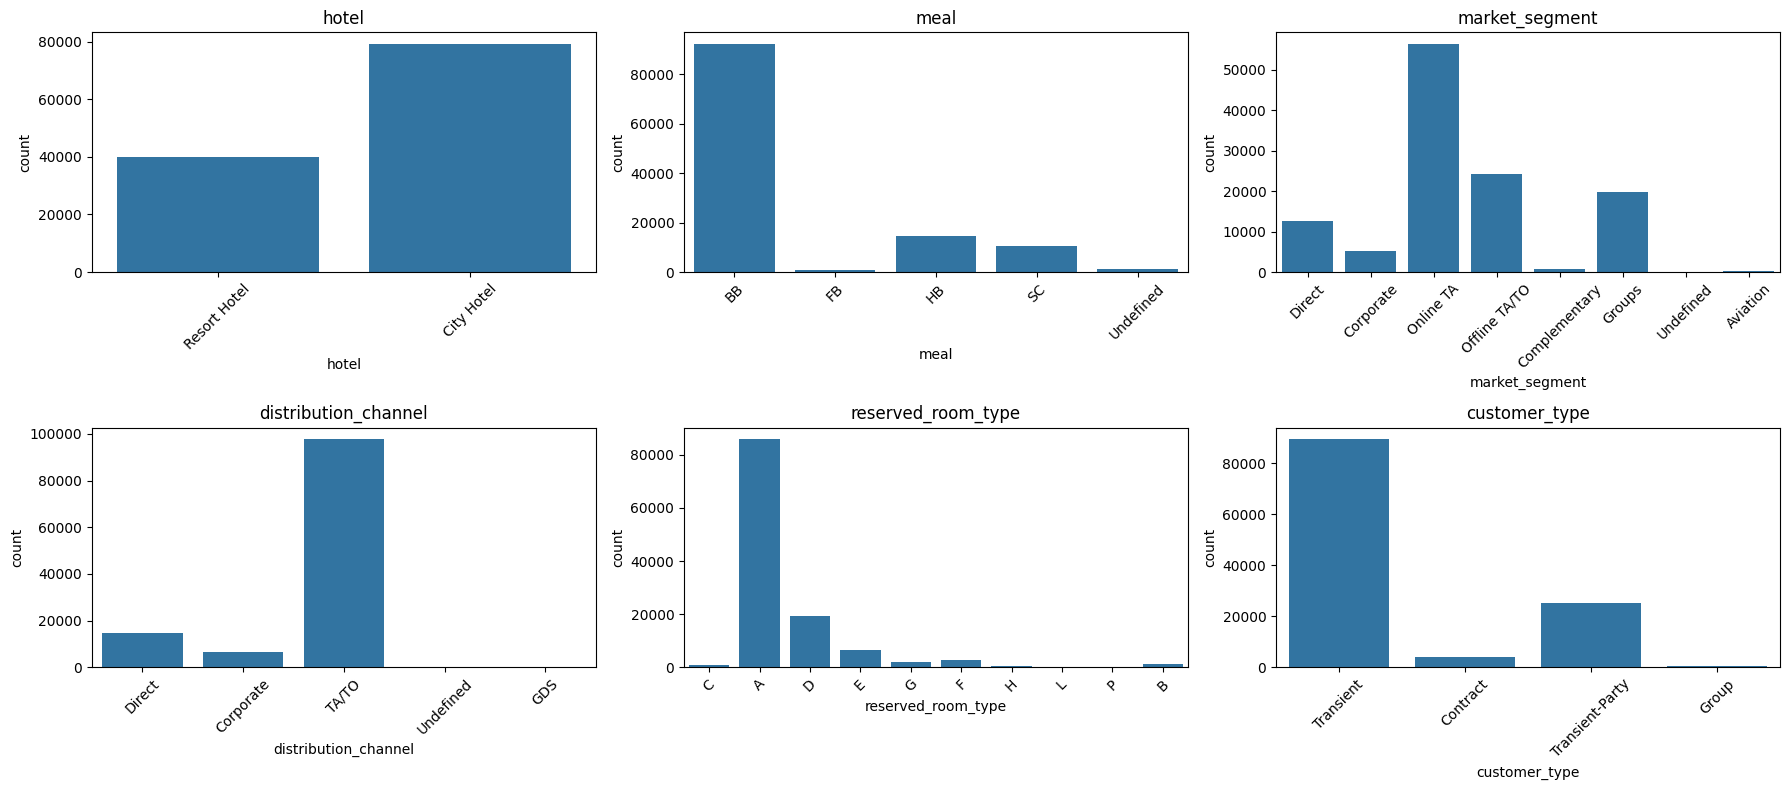

In [53]:

#3.1 Separate numerical and categorical columns

# Numerical plots
df[num_cols].hist(figsize=(16, 12), bins=20, edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

import math

n = len(cat_cols)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows*4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
  sns.countplot(x=col, data=df, ax=axes[i])
  axes[i].set_title(col)
  axes[i].tick_params(axis='x', rotation=45)


for j in range(i+1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



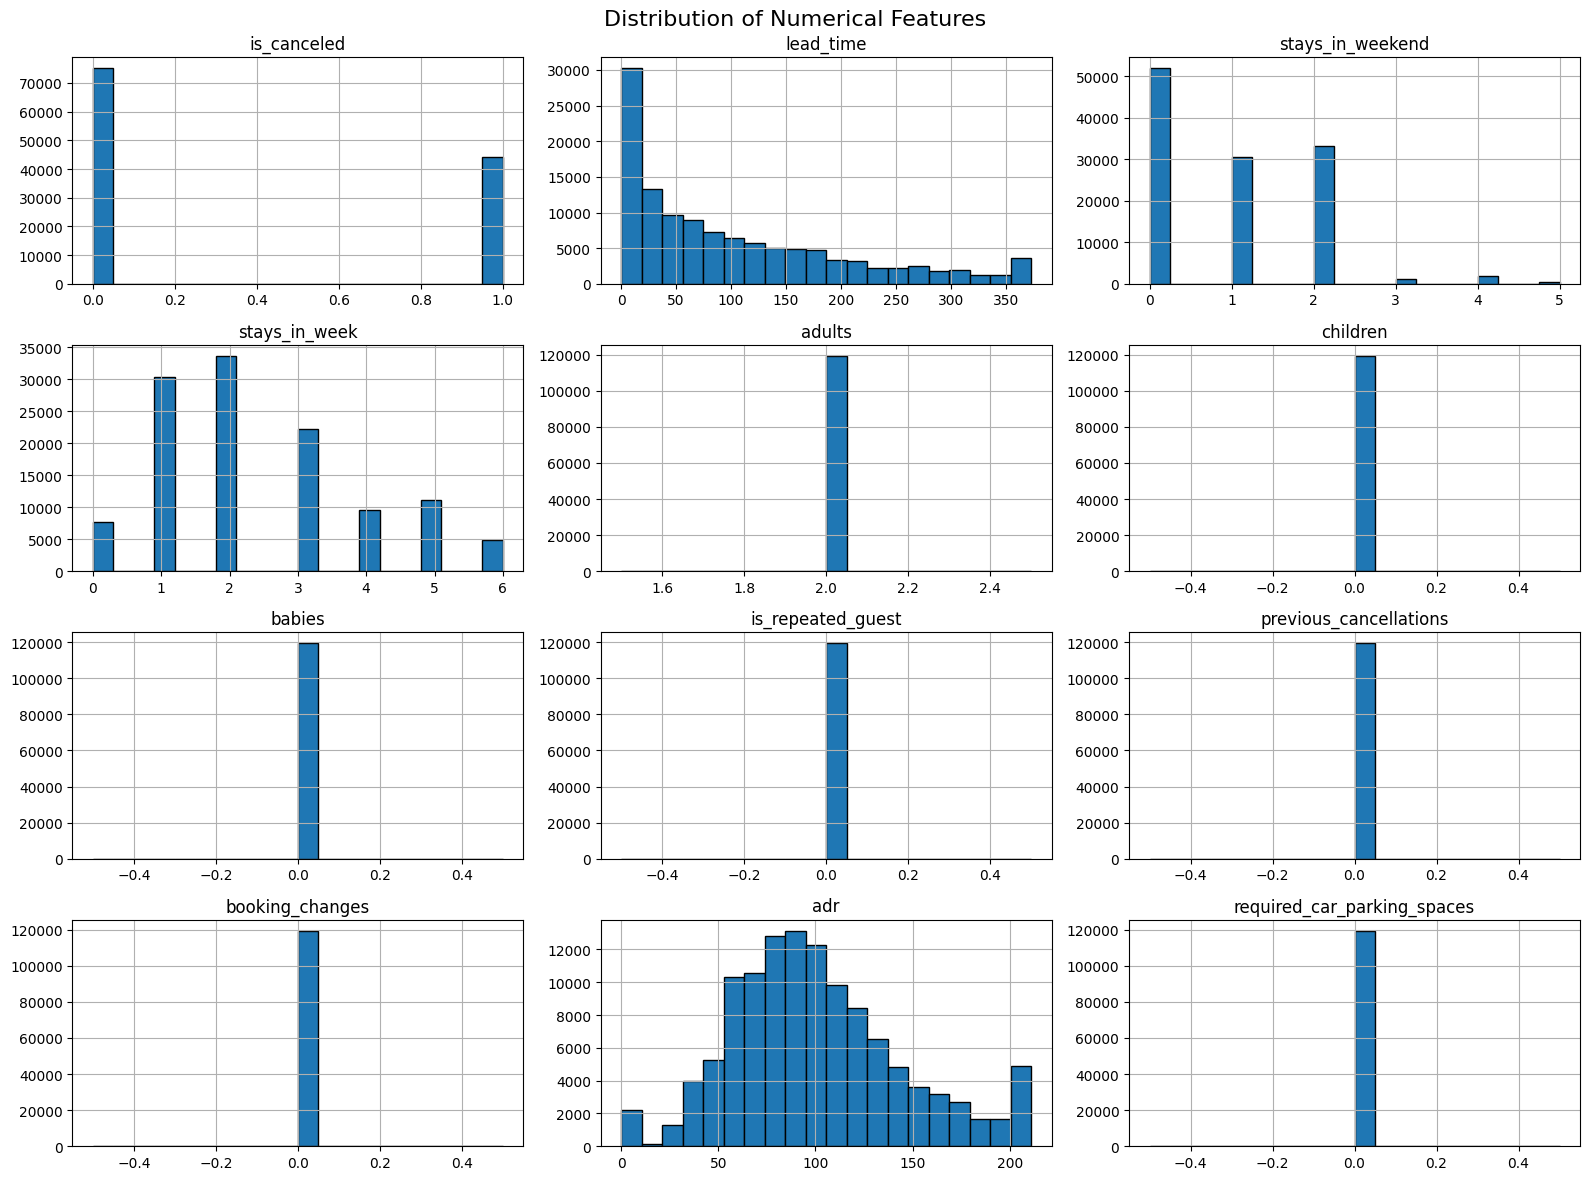

In [54]:
#3.2 distribution of numerical features

df[num_cols].hist(figsize=(16, 12), bins=20, edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

Insight: The distribution of numerical features shows how each numerical feature is distributed across the dataset.
We can identify:
Skewed distributions (e.g., lead_time may have longer bookings).

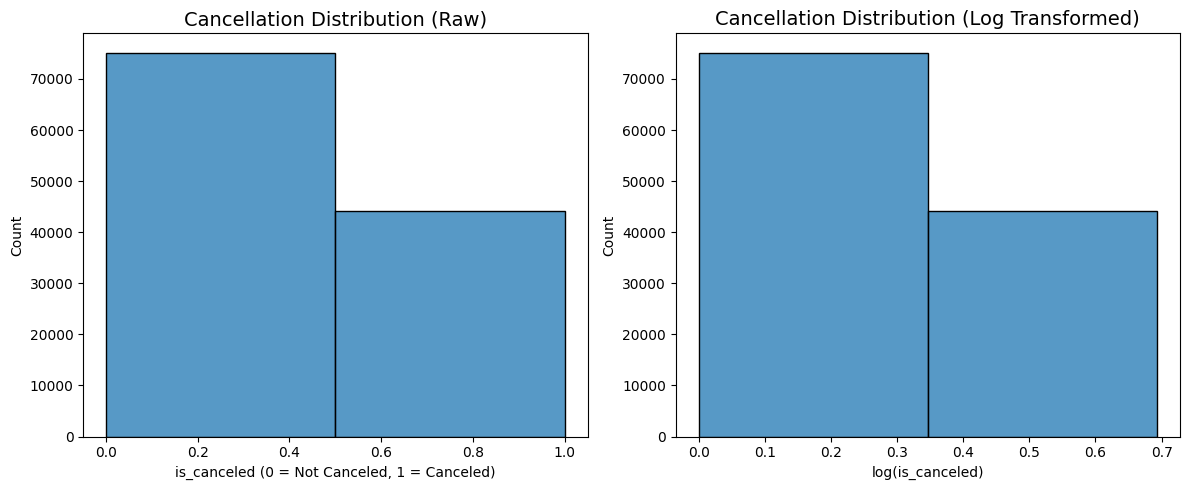

Cancellation Stats:
Mean: 0.37041628277075134
Std: 0.48291822659316763


In [57]:
#3.3 Target variable distribution

#Raw target distribution
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['is_canceled'], bins=2, kde=False)
plt.title("Cancellation Distribution (Raw)", fontsize=14)
plt.xlabel("is_canceled (0 = Not Canceled, 1 = Canceled)")
plt.ylabel("Count")

# Log Transformed (to indicate imbalanced variables)
plt.subplot(1,2,2)
log_vals = np.log1p(df['is_canceled'])
sns.histplot(log_vals, bins=2, kde=False)
plt.title("Cancellation Distribution (Log Transformed)", fontsize=14)
plt.xlabel("log(is_canceled)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

print("Cancellation Stats:")
print("Mean:", df['is_canceled'].mean())
print("Std:", df['is_canceled'].std())


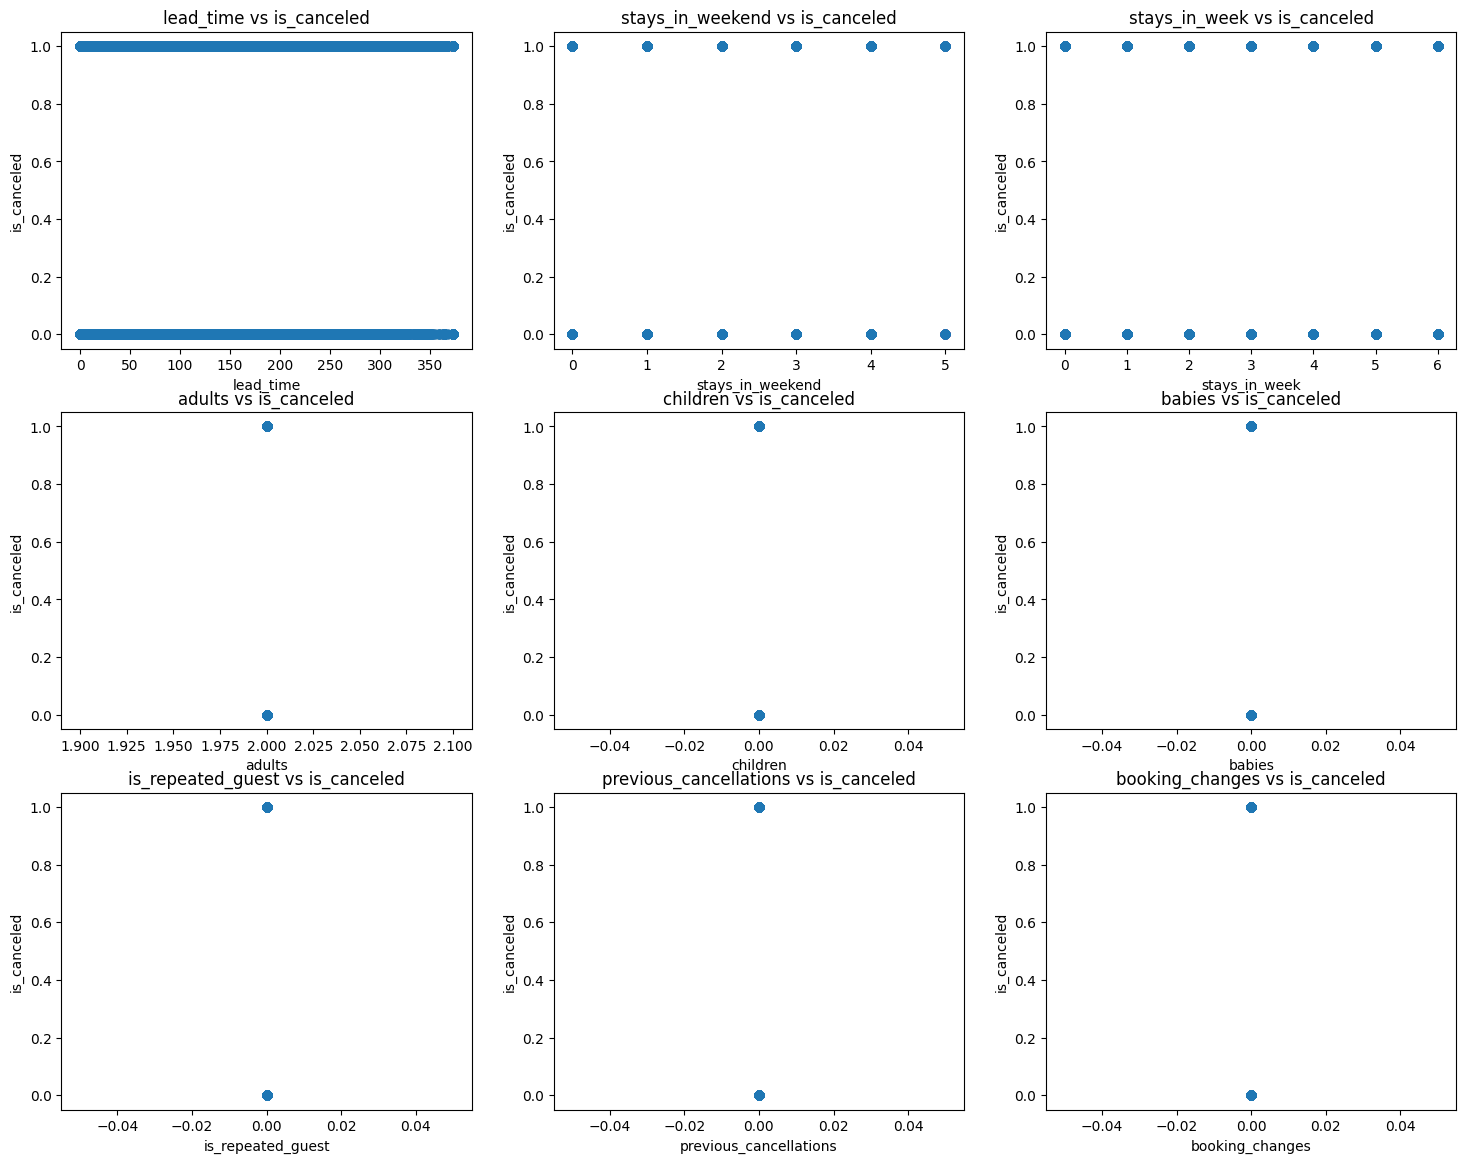

In [62]:
#3.4 Numerical features vs Target variable

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('is_canceled')

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols[:9]): # limit to first 9 for clean layout
 axes[i].scatter(df[col], df['is_canceled'], alpha=0.3)
 axes[i].set_title(f"{col} vs is_canceled")
 axes[i].set_xlabel(col)
 axes[i].set_ylabel("is_canceled")


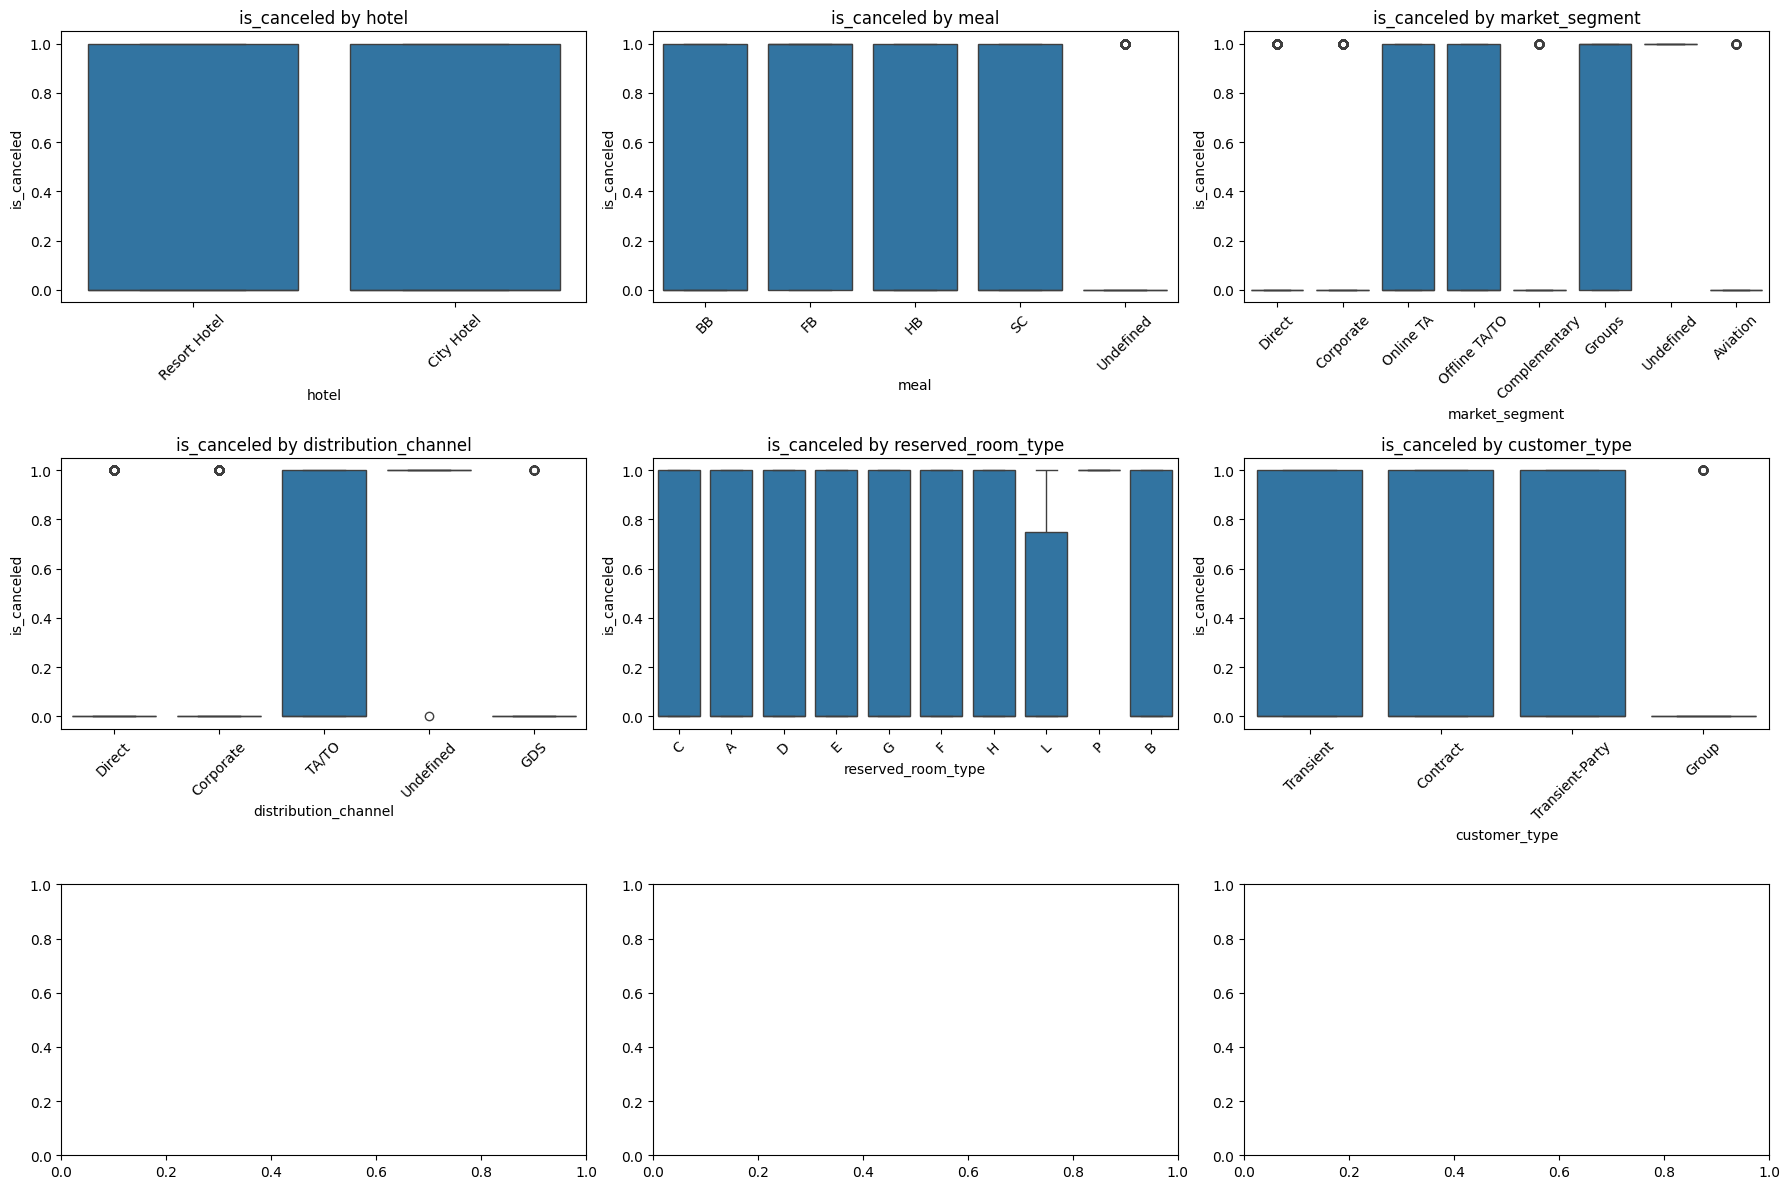

In [63]:
# 3.5 categorical columns vs target variable
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# plot boxplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:9]): # limit for clean layout
 sns.boxplot(x=col, y='is_canceled', data=df, ax=axes[i])
 axes[i].set_title(f"is_canceled by {col}")
 axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

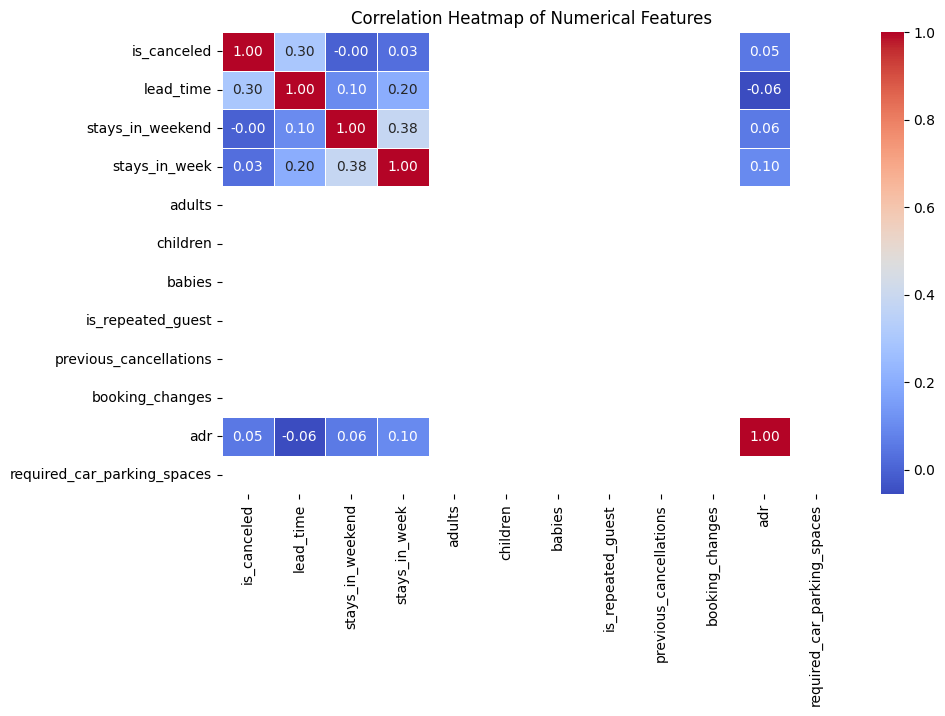

In [65]:
#3.6 # Calculate correlation matrix for numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

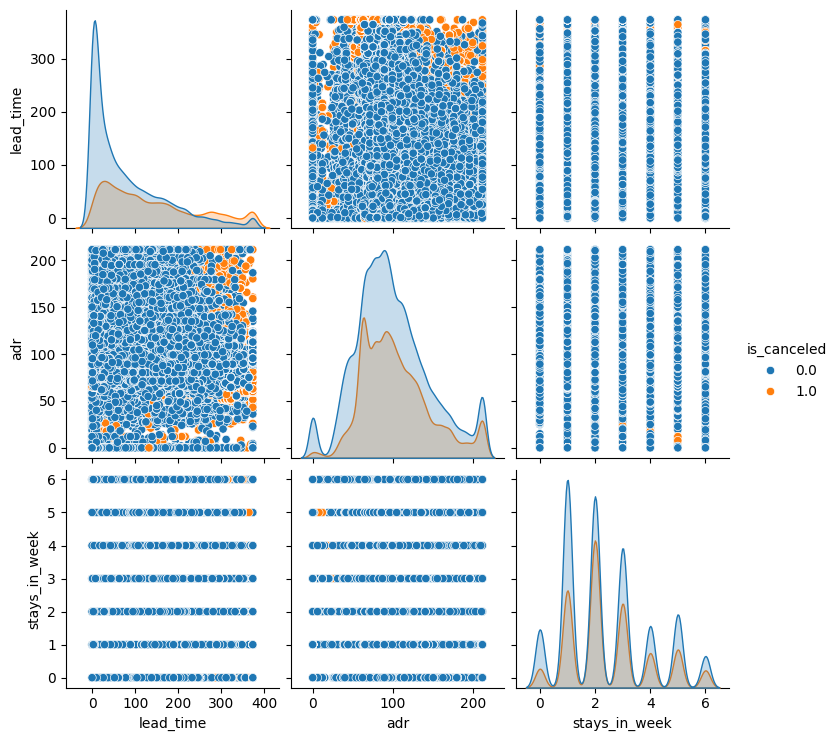

In [67]:
#3.7 Pairplot (Important variables only)
pair_cols = ['lead_time', 'adr', 'stays_in_week', 'is_canceled']

# Pairplot
sns.pairplot(df[pair_cols], hue='is_canceled')
plt.show()

Insight : EDA was performed using histograms, count plots, scatter plots, boxplots, pairplots, and correlation heatmaps to understand patterns and relationships in the dataset. The analysis showed that variables such as lead time, ADR, previous cancellations, customer type, and market segment strongly influence hotel booking cancellations. EDA also helped identify outliers, trends, and important predictors, providing a strong foundation for feature selection and model building.

# Model building before selecting features

In [109]:

# Decision Tree Model
# X and y (ALL features)
X = df_encoded.drop("is_canceled", axis=1)
y = df_encoded["is_canceled"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42, stratify=y)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

print("BEFORE Feature Selection - Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))



BEFORE Feature Selection - Decision Tree
Accuracy: 0.7722310634614847
Precision: 0.689292330492775
Recall: 0.7011381623577297
F1 Score: 0.6951647858904416
ROC-AUC: 0.7611568640460794


In [70]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("\nBEFORE Feature Selection - Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))



BEFORE Feature Selection - Random Forest
Accuracy: 0.8048691961917526
Precision: 0.7644927536231884
Recall: 0.6838772895153388
F1 Score: 0.7219415158146012
ROC-AUC: 0.8731407220990948


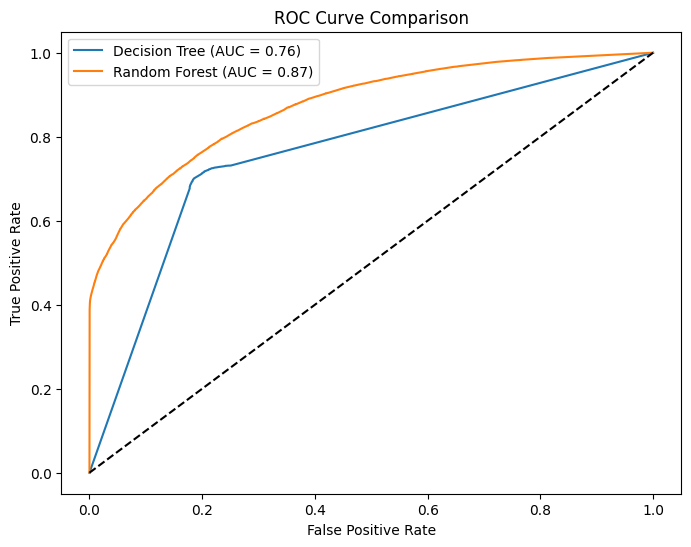

In [71]:
#Combine both features
from sklearn.metrics import roc_curve, auc

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


Insight: Before feature selection, multiple classification models including Logistic Regression, Decision Tree, Random Forest, and KNN were trained using all available features in the dataset. This helped establish a baseline performance for comparison.



#4. Feature Selection

In [72]:
#4.1 RFE (Recursive Feature Elimination)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

X = df_encoded.drop('is_canceled', axis=1)
y = df_encoded['is_canceled']

model = LogisticRegression(max_iter=1000)

rfe = RFE(model, n_features_to_select=5)
rfe.fit(X, y)

rfe_features = X.columns[rfe.support_]

print("RFE Selected Features:")
print(rfe_features)

RFE Selected Features:
Index(['adults', 'meal_Undefined', 'market_segment_Groups',
       'distribution_channel_TA/TO', 'customer_type_Transient'],
      dtype='object')


                          Feature  Importance
0                       lead_time    0.330312
9                             adr    0.264534
2                   stays_in_week    0.083396
38  customer_type_Transient-Party    0.072640
1                stays_in_weekend    0.047024
19          market_segment_Groups    0.034465
11             hotel_Resort Hotel    0.029344
37        customer_type_Transient    0.025636
29           reserved_room_type_D    0.018607
13                        meal_HB    0.014151


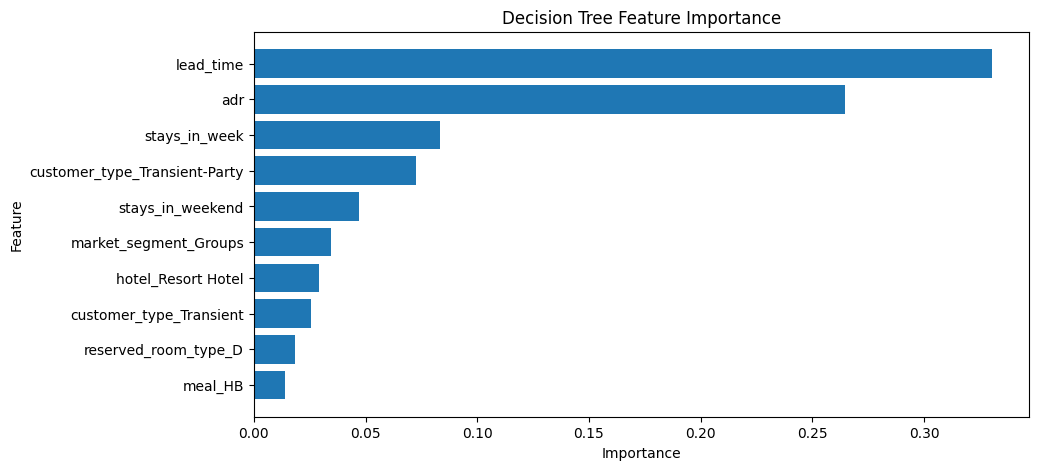

In [75]:
#4.2 Decision Tree Feature Importance
from sklearn.tree import DecisionTreeClassifier

# X and y
X = df_encoded.drop("is_canceled", axis=1)
y = df_encoded["is_canceled"]

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X, y)

# Create feature importance dataframe
dt_importance = pd.DataFrame({
"Feature": X.columns,
"Importance": dt_model.feature_importances_
})

dt_importance = dt_importance.sort_values(by="Importance", ascending=False)

# Show top 10 important features
print(dt_importance.head(10))

# Visualize top 10
top_dt = dt_importance.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_dt["Feature"], top_dt["Importance"])
plt.gca().invert_yaxis()
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()



                          Feature  Importance
0                       lead_time    0.375129
9                             adr    0.296378
2                   stays_in_week    0.061624
19          market_segment_Groups    0.044088
1                stays_in_weekend    0.036463
38  customer_type_Transient-Party    0.032052
37        customer_type_Transient    0.030837
11             hotel_Resort Hotel    0.017968
21       market_segment_Online TA    0.015327
25     distribution_channel_TA/TO    0.014249


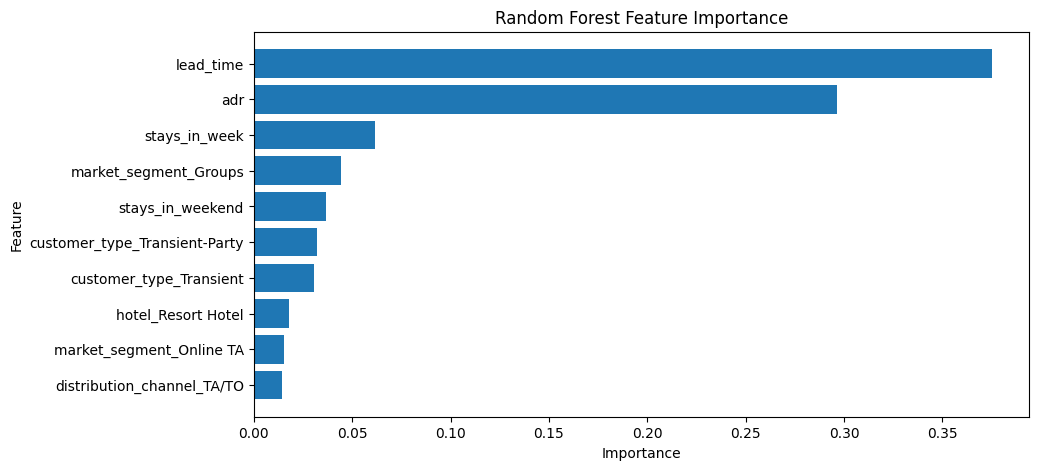

In [76]:
#4.3 Random Forest Feature Importance
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# X and y
X = df_encoded.drop("is_canceled", axis=1)
y = df_encoded["is_canceled"]

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Create feature importance dataframe
rf_importance = pd.DataFrame({
"Feature": X.columns,
"Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

# Show top 10
print(rf_importance.head(10))

# Plot top 10
top_rf = rf_importance.head(10)

plt.figure(figsize=(10,5))
plt.barh(top_rf["Feature"], top_rf["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [79]:

#4.4 FINAL FEATURE SELECTION (Combine RFE + Decision Tree + Random Forest)

import pandas as pd

# Top features from each method
rfe_features = X.columns[rfe.support_].tolist()
dt_features = dt_importance.head(15)["Feature"].tolist()
rf_features = rf_importance.head(15)["Feature"].tolist()

# Combine into one dataframe
feature_votes = pd.DataFrame({
"Feature": list(set(rfe_features + dt_features + rf_features))
})

feature_votes["RFE"] = feature_votes["Feature"].isin(rfe_features).astype(int)
feature_votes["Decision_Tree"] = feature_votes["Feature"].isin(dt_features).astype(int)
feature_votes["Random_Forest"] = feature_votes["Feature"].isin(rf_features).astype(int)

# Count how many methods selected each feature
feature_votes["Total_Votes"] = (
feature_votes["RFE"] +
feature_votes["Decision_Tree"] +
feature_votes["Random_Forest"]
)

# Sort by importance agreement
feature_votes = feature_votes.sort_values(by="Total_Votes", ascending=False)

print("Feature Selection Comparison:")
print(feature_votes)

# Final selected features: chosen by at least 2 methods
final_selected_features = feature_votes[feature_votes["Total_Votes"] >= 2]["Feature"].tolist()

print("\nFinal Selected Features:")
print(final_selected_features)

print("\nShape before feature selection:", X.shape)

X_selected = X[final_selected_features]

print("Shape after feature selection:", X_selected.shape)



Feature Selection Comparison:
                          Feature  RFE  Decision_Tree  Random_Forest  \
4         customer_type_Transient    1              1              1   
17          market_segment_Groups    1              1              1   
0                             adr    0              1              1   
2      distribution_channel_TA/TO    1              0              1   
1                         meal_HB    0              1              1   
5              hotel_Resort Hotel    0              1              1   
3        market_segment_Online TA    0              1              1   
8                stays_in_weekend    0              1              1   
9                   stays_in_week    0              1              1   
11   market_segment_Offline TA/TO    0              1              1   
6   customer_type_Transient-Party    0              1              1   
18           reserved_room_type_D    0              1              1   
13                      lead_time 

Insight: Feature selection was performed to identify the most important variables that strongly influence hotel booking cancellations. RFE, Decision Tree Feature Importance, and Random Forest Feature Importance were used to rank and select significant predictors.

#5. Model Building

In [80]:
#5.1 Logistic regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Logistic Regression
Accuracy: 0.7247954881760058
Precision: 0.7096655189375307
Recall: 0.43498907062636616
F1: 0.5393709986447965
ROC-AUC: 0.7505458753752245


Insight: Logistic Regression: The model achieved moderate performance and provided a strong baseline for comparison. Its F1 Score and ROC-AUC showed that the dataset contains meaningful patterns related to hotel booking cancellations.


In [83]:
#5.2 Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train model
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

# Results (clean output only)
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Decision Tree Results
Accuracy: 0.720942569171064
Precision: 0.8554976097348979
Recall: 0.29675133790608277
F1 Score: 0.44065140746544296
ROC-AUC: 0.7660955069653343


Insight: Decision Tree: The model produced better classification performance by capturing non-linear relationships in the data.


In [84]:
#5.3 Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


Random Forest
Accuracy: 0.8048691961917526
Precision: 0.7644927536231884
Recall: 0.6838772895153388
F1: 0.7219415158146012
ROC-AUC: 0.8731407220990948


Insight: Random Forest: This model achieved the highest Accuracy, F1 Score, and ROC-AUC among all models, making it the best-performing model for predicting hotel booking cancellations.

In [85]:
#5.4 K-Nearest Neighbours Model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:,1]

print("\nKNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))



KNN
Accuracy: 0.7586900075383198
Precision: 0.6933757109401137
Recall: 0.624858671892666
F1: 0.6573365579035008
ROC-AUC: 0.8114311538039217


Insight: Its performance was affected by sensitivity to feature scaling and data distribution.

# Model comparison BEFORE optimization

In [86]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

comparison_before_optimization = pd.DataFrame({
"Model": [
"Logistic Regression",
"Decision Tree",
"Random Forest",
"KNN"
],
"Accuracy": [
accuracy_score(y_test, y_pred_log),
accuracy_score(y_test, y_pred_dt),
accuracy_score(y_test, y_pred_rf),
accuracy_score(y_test, y_pred_knn)
],
"Precision": [
precision_score(y_test, y_pred_log),
precision_score(y_test, y_pred_dt),
precision_score(y_test, y_pred_rf),
precision_score(y_test, y_pred_knn)
],
"Recall": [
recall_score(y_test, y_pred_log),
recall_score(y_test, y_pred_dt),
recall_score(y_test, y_pred_rf),
recall_score(y_test, y_pred_knn)
],
"F1 Score": [
f1_score(y_test, y_pred_log),
f1_score(y_test, y_pred_dt),
f1_score(y_test, y_pred_rf),
f1_score(y_test, y_pred_knn)
],
"ROC-AUC": [
roc_auc_score(y_test, y_prob_log),
roc_auc_score(y_test, y_prob_dt),
roc_auc_score(y_test, y_prob_rf),
roc_auc_score(y_test, y_prob_knn)
]
})

comparison_before_optimization

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.724795,0.709666,0.434989,0.539371,0.750546
1,Decision Tree,0.772231,0.689292,0.701138,0.695165,0.761157
2,Random Forest,0.804869,0.764493,0.683877,0.721942,0.873141
3,KNN,0.758690,0.693376,0.624859,0.657337,0.811431


# Find best model based on F1 Score

In [87]:
best_model = comparison_before_optimization.sort_values(
by="F1 Score",
ascending=False
).iloc[0]

print("Best Model Before Optimization:")
print(best_model)

Best Model Before Optimization:
Model        Random Forest
Accuracy          0.804869
Precision         0.764493
Recall            0.683877
F1 Score          0.721942
ROC-AUC           0.873141
Name: 2, dtype: object


#6. Model Optimization

In [88]:
#6.1 Logistic Regression Optimization
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid_log = {
"C": [0.01, 0.1, 1, 10],
"penalty": ["l2"],
"solver": ["lbfgs"]
}

log_model = LogisticRegression(max_iter=1000)

grid_log = GridSearchCV(
estimator=log_model,
param_grid=param_grid_log,
cv=3,
scoring="f1",
n_jobs=-1
)

grid_log.fit(X_train, y_train)

print("Best Parameters (Logistic):")
print(grid_log.best_params_)

print("Best F1 Score (CV):")
print(grid_log.best_score_)


Best Parameters (Logistic):
{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best F1 Score (CV):
0.5405167518837933


Insight: Logistic Regression Optimization: GridSearchCV improved the model’s performance by selecting the best hyperparameters, resulting in better F1 Score and ROC-AUC.


In [89]:
#Evaluate optimized logistic Model
best_log = grid_log.best_estimator_

y_pred_log_opt = best_log.predict(X_test)
y_prob_log_opt = best_log.predict_proba(X_test)[:,1]

print("\nOptimized Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log_opt))
print("Precision:", precision_score(y_test, y_pred_log_opt))
print("Recall:", recall_score(y_test, y_pred_log_opt))
print("F1 Score:", f1_score(y_test, y_pred_log_opt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log_opt))


Optimized Logistic Regression
Accuracy: 0.7243487729290561
Precision: 0.7085278938314082
Recall: 0.43461219567347553
F1 Score: 0.5387526278906798
ROC-AUC: 0.7504845759538403


In [90]:
#6.2 5-Fold Cross Validation
from sklearn.ensemble import RandomForestClassifier
#  5-Fold Cross Validation
# Parameter grid
param_grid = {
"n_estimators": [100, 200],
"max_depth": [5, 10, None],
"min_samples_split": [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
estimator=rf,
param_grid=param_grid,
cv=5,
scoring="f1",
n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 Score: 0.7119715585424541


Insight: 5-Fold Cross-Validation: Cross-validation showed consistent model performance across different data splits, confirming that the model is stable and reliable.

In [91]:
#Evaluate optimized model
best_rf = grid.best_estimator_

y_pred_opt = best_rf.predict(X_test)
y_prob_opt = best_rf.predict_proba(X_test)[:,1]

print("Optimized Random Forest (5-Fold CV)")
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("F1 Score:", f1_score(y_test, y_pred_opt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_opt))


Optimized Random Forest (5-Fold CV)
Accuracy: 0.805678867576849
F1 Score: 0.7230401910067649
ROC-AUC: 0.8742184808446412


In [100]:
#6.3 Cross Validation scores (all models)
from sklearn.model_selection import cross_val_score

# Use selected features
X_final = X[final_selected_features]
y = df_encoded['is_canceled']

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
"Logistic Regression": LogisticRegression(max_iter=1000),
"Decision Tree": DecisionTreeClassifier(random_state=42),
"Random Forest": RandomForestClassifier(random_state=42),
"KNN": KNeighborsClassifier()
}

# Cross-validation (5-fold)
cv_results = []

for name, model in models.items():
 scores = cross_val_score(model, X_final, y, cv=5, scoring='f1')
 cv_results.append({
 "Model": name,
"Mean F1 Score": scores.mean(),
 "Std Dev": scores.std()
 })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,Mean F1 Score,Std Dev
0,Logistic Regression,0.466399,0.178072
1,Decision Tree,0.373349,0.069865
2,Random Forest,0.359581,0.112464
3,KNN,0.383110,0.064635


#7. Model evaluation and validation

In [102]:
#7.1 Total Comaprison Table
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

comparison_final = pd.DataFrame({
"Model": [
"Logistic Regression",
"Decision Tree",
"Random Forest (Optimized)",
"KNN"
],

"Accuracy": [
accuracy_score(y_test, y_pred_log_opt),
accuracy_score(y_test, y_pred_dt),
accuracy_score(y_test, y_pred_opt),
accuracy_score(y_test, y_pred_knn)
],

"Precision": [
precision_score(y_test, y_pred_log_opt),
precision_score(y_test, y_pred_dt),
precision_score(y_test, y_pred_opt),
precision_score(y_test, y_pred_knn)
],

"Recall": [
recall_score(y_test, y_pred_log_opt),
recall_score(y_test, y_pred_dt),
recall_score(y_test, y_pred_opt),
recall_score(y_test, y_pred_knn)
],

"F1 Score": [
f1_score(y_test, y_pred_log_opt),
f1_score(y_test, y_pred_dt),
f1_score(y_test, y_pred_opt),
f1_score(y_test, y_pred_knn)
],

"ROC-AUC": [
roc_auc_score(y_test, y_prob_log_opt),
roc_auc_score(y_test, y_prob_dt),
roc_auc_score(y_test, y_prob_opt),
roc_auc_score(y_test, y_prob_knn)
]
})

# Sort by best model
comparison_final = comparison_final.sort_values(by="F1 Score", ascending=False)

comparison_final


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest (Optimized),0.805679,0.765827,0.684782,0.723040,0.874218
1,Decision Tree,0.772231,0.689292,0.701138,0.695165,0.761157
3,KNN,0.758690,0.693376,0.624859,0.657337,0.811431
0,Logistic Regression,0.724349,0.708528,0.434612,0.538753,0.750485


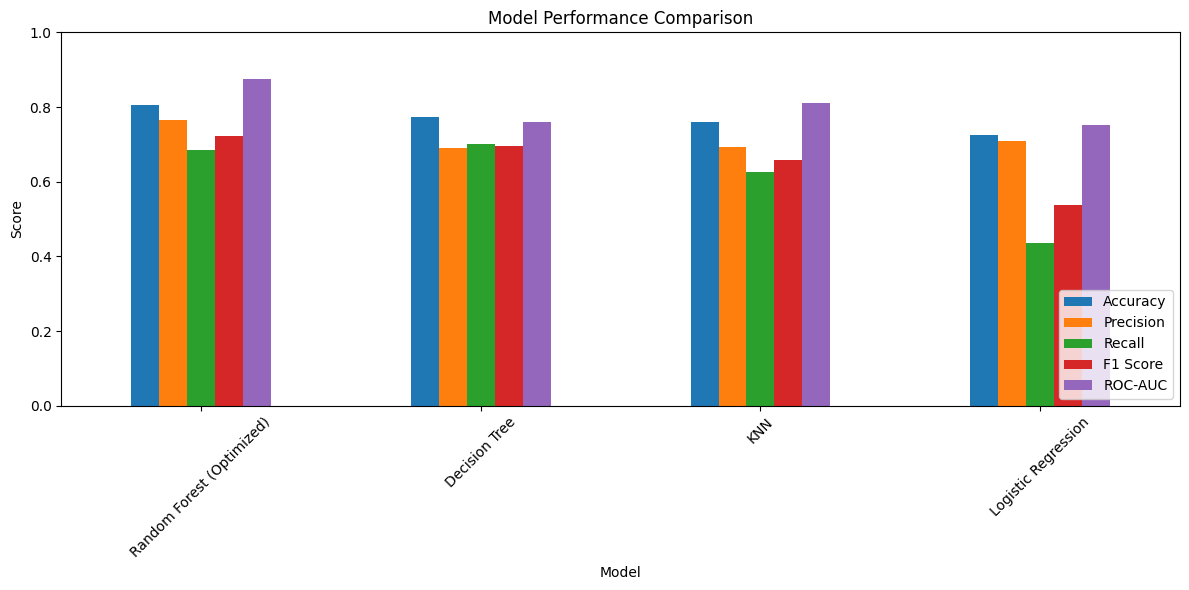

In [103]:
#7.2 Visual Comparison
comparison_final.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
kind="bar",
figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


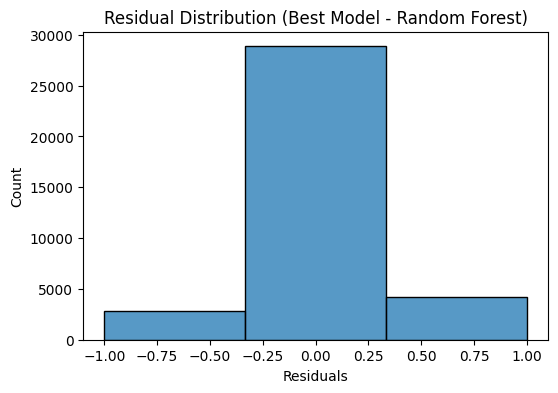

In [104]:
#7.3 Best Model resuidal analysis
residuals = y_test - y_pred_opt # optimized RF

# Plot
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=3)

plt.title("Residual Distribution (Best Model - Random Forest)")
plt.xlabel("Residuals")
plt.ylabel("Count")

plt.show()

#Comparison before and after feature selection

In [108]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# BEFORE FEATURE SELECTION

before_fs = pd.DataFrame({
"Stage": ["Before Feature Selection"] * 4,
"Model": [
"Logistic Regression",
"Decision Tree",
"Random Forest",
"KNN"
],
"Accuracy": [
accuracy_score(y_test, y_pred_log),
accuracy_score(y_test, y_pred_dt),
accuracy_score(y_test, y_pred_rf),
accuracy_score(y_test, y_pred_knn)
],
"Precision": [
precision_score(y_test, y_pred_log),
precision_score(y_test, y_pred_dt),
precision_score(y_test, y_pred_rf),
precision_score(y_test, y_pred_knn)
],
"Recall": [
recall_score(y_test, y_pred_log),
recall_score(y_test, y_pred_dt),
recall_score(y_test, y_pred_rf),
recall_score(y_test, y_pred_knn)
],
"F1 Score": [
f1_score(y_test, y_pred_log),
f1_score(y_test, y_pred_dt),
f1_score(y_test, y_pred_rf),
f1_score(y_test, y_pred_knn)
],
"ROC-AUC": [
roc_auc_score(y_test, y_prob_log),
roc_auc_score(y_test, y_prob_dt),
roc_auc_score(y_test, y_prob_rf),
roc_auc_score(y_test, y_prob_knn)
]
})

# AFTER FEATURE SELECTION

after_fs = pd.DataFrame({
"Stage": ["After Feature Selection"] * 4,
"Model": [
"Logistic Regression",
"Decision Tree",
"Random Forest",
"KNN"
],
"Accuracy": [
accuracy_score(y_test, y_pred_log_opt),
accuracy_score(y_test, y_pred_dt),
accuracy_score(y_test, y_pred_opt),
accuracy_score(y_test, y_pred_knn)
],
"Precision": [
precision_score(y_test, y_pred_log_opt),
precision_score(y_test, y_pred_dt),
precision_score(y_test, y_pred_opt),
precision_score(y_test, y_pred_knn)
],
"Recall": [
recall_score(y_test, y_pred_log_opt),
recall_score(y_test, y_pred_dt),
recall_score(y_test, y_pred_opt),
recall_score(y_test, y_pred_knn)
],
"F1 Score": [
f1_score(y_test, y_pred_log_opt),
f1_score(y_test, y_pred_dt),
f1_score(y_test, y_pred_opt),
f1_score(y_test, y_pred_knn)
],
"ROC-AUC": [
roc_auc_score(y_test, y_prob_log_opt),
roc_auc_score(y_test, y_prob_dt),
roc_auc_score(y_test, y_prob_opt),
roc_auc_score(y_test, y_prob_knn)
]
})

# COMBINE BOTH TABLES
fs_comparison = pd.concat([before_fs, after_fs], ignore_index=True)

fs_comparison
side_by_side = fs_comparison.pivot(
index="Model",
columns="Stage",
values=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

side_by_side


Accuracy                           \
Stage               After Feature Selection Before Feature Selection   
Model                                                                  
Decision Tree                      0.772231                 0.772231   
KNN                                0.758690                 0.758690   
Logistic Regression                0.724349                 0.724795   
Random Forest                      0.805679                 0.804869   

                                  Precision                           \
Stage               After Feature Selection Before Feature Selection   
Model                                                                  
Decision Tree                      0.689292                 0.689292   
KNN                                0.693376                 0.693376   
Logistic Regression                0.708528                 0.709666   
Random Forest                      0.765827                 0.764493   

                                     Recall                           \
Stage               After Feature Selection Before Feature Selection   
Model                                                                  
Decision Tree                      0.701138                 0.701138   
KNN                                0.624859                 0.624859   
Logistic Regression                0.434612                 0.434989   
Random Forest                      0.684782                 0.683877   

                                   F1 Score                           \
Stage               After Feature Selection Before Feature Selection   
Model                                                                  
Decision Tree                      0.695165                 0.695165   
KNN                                0.657337                 0.657337   
Logistic Regression                0.538753                 0.539371   
Random Forest                      0.723040                 0.721942   

                                    ROC-AUC                           
Stage               After Feature Selection Before Feature Selection  
Model                                                                 
Decision Tree                      0.761157                 0.761157  
KNN                                0.811431                 0.811431  
Logistic Regression                0.750485                 0.750546  
Random Forest                      0.874218                 0.873141

#8. Business Insights and Recommendation

<h2>8.1 Business Insights & Recommendations</h2>

<table border="1" cellpadding="10" cellspacing="0" width="100%">

<tr>
<th>Business Insight</th>
<th>Recommendation</th>
</tr>

<tr>
<td><b>High lead time increases cancellation risk</b></td>
<td>Send reminder emails and confirmation messages to customers who book far in advance</td>
</tr>

<tr>
<td><b>Customers with previous cancellations are more likely to cancel again</b></td>
<td>Apply stricter cancellation policies or request advance deposits</td>
</tr>

<tr>
<td><b>Higher ADR may increase cancellation probability</b></td>
<td>Use dynamic pricing and promotional offers during high-price periods</td>
</tr>

<tr>
<td><b>Transient customers cancel more frequently</b></td>
<td>Create loyalty programs and personalized retention offers</td>
</tr>

<tr>
<td><b>Online booking channels show higher cancellation rates</b></td>
<td>Introduce flexible but controlled cancellation policies for online bookings</td>
</tr>

<tr>
<td><b>Random Forest achieved the best model performance</b></td>
<td>Use Random Forest as the preferred predictive model for hotel cancellation management</td>
</tr>

</table>


#8.2 How Businesses Can Apply This Model

1. Revenue Management
Hotels can predict cancellation risk early and improve pricing strategies to reduce revenue loss.

2. Customer Retention
Hotels can target high-risk customers with reminders, discounts, or loyalty offers.

3. Operational Planning
Hotels can improve room allocation, staffing, and overbooking decisions using cancellation predictions.

4. Smart Decision-Making
Managers can use machine learning insights to support data-driven business strategies.

<h2>8.3. Model Selection Summary</h2>

<table border="1" cellpadding="10" cellspacing="0" width="100%">
<tr>
<th>Model</th>
<th>Why It Was Selected</th>
</tr>

<tr>
<td><b>Logistic Regression</b></td>
<td>Used as a simple and interpretable baseline classification model</td>
</tr>

<tr>
<td><b>Decision Tree</b></td>
<td>Selected for its ability to capture non-linear relationships and easy interpretability</td>
</tr>

<tr>
<td><b>Random Forest</b></td>
<td>Chosen because it reduces overfitting and provides strong predictive performance through ensemble learning</td>
</tr>

<tr>
<td><b>K-Nearest Neighbors (KNN)</b></td>
<td>Included to compare instance-based learning performance with other classification models</td>
</tr>

</table>


<h2>8.4. Limitations & Future Improvements</h2>

<table border="1" cellpadding="10" cellspacing="0" width="100%">

<tr>
<th>Limitations</th>
<th>Future Improvements</th>
</tr>

<tr>
<td><b>The dataset contains limited historical booking information</b></td>
<td>Include real-time booking and customer behavior data</td>
</tr>

<tr>
<td><b>External factors such as weather and events were not included</b></td>
<td>Add external variables to improve prediction accuracy</td>
</tr>

<tr>
<td><b>Some models may still produce false predictions</b></td>
<td>Apply advanced machine learning and deep learning models</td>
</tr>

<tr>
<td><b>Feature selection may remove some useful variables</b></td>
<td>Perform additional feature engineering and testing</td>
</tr>

<tr>
<td><b>The model was trained on one hotel booking dataset only</b></td>
<td>Validate the model using multiple hotel datasets</td>
</tr>

<tr>
<td><b>KNN and Decision Tree can be sensitive to data distribution</b></td>
<td>Further optimize hyperparameters and test more robust algorithms</td>
</tr>

</table>


In [115]:
# ================= FINAL SUMMARY =================

best_model = comparison_final.iloc[0]

print("Final model selected based on highest F1 Score and ROC-AUC")
print("==============================================================")

print("""
╔══════════════════════════════════════════════════════════════╗
║ MIS444 – Hotel Booking Cancellation Prediction ║
╚══════════════════════════════════════════════════════════════╝
""")

print(f"""
║ Dataset Size : {df.shape[0]} records, {df.shape[1]} columns
║ Problem Type : Classification
║ Models Trained : 4 (Logistic Regression, DT, RF, KNN)
║ Feature Selection : RFE + Decision Tree + Random Forest
║ Optimization Method : GridSearchCV + 5-Fold Cross Validation
""")

print("--------------------------------------------------------------")

print(f"""
║ Best Model : {best_model['Model']}
║ Accuracy : {best_model['Accuracy']:.4f}
║ Precision : {best_model['Precision']:.4f}
║ Recall : {best_model['Recall']:.4f}
║ F1 Score : {best_model['F1 Score']:.4f}
║ ROC-AUC : {best_model['ROC-AUC']:.4f}
""")

print("==============================================================")

Final model selected based on highest F1 Score and ROC-AUC

╔══════════════════════════════════════════════════════════════╗
║ MIS444 – Hotel Booking Cancellation Prediction ║
╚══════════════════════════════════════════════════════════════╝


║ Dataset Size : 119390 records, 18 columns
║ Problem Type : Classification
║ Models Trained : 4 (Logistic Regression, DT, RF, KNN)
║ Feature Selection : RFE + Decision Tree + Random Forest
║ Optimization Method : GridSearchCV + 5-Fold Cross Validation

--------------------------------------------------------------

║ Best Model : Random Forest (Optimized)
║ Accuracy : 0.8057
║ Precision : 0.7658
║ Recall : 0.6848
║ F1 Score : 0.7230
║ ROC-AUC : 0.8742



# Conclusion
This project successfully applied predictive analytics and machine learning techniques to predict hotel booking cancellations using multiple classification models.

Exploratory Data Analysis (EDA), feature selection, model optimization, and cross-validation were performed to improve prediction accuracy and reduce overfitting.

Among all models, the optimized Random Forest model achieved the best overall performance based on F1 Score and ROC-AUC, making it the most reliable model for predicting hotel booking cancellations.

The project demonstrates how machine learning can help hotels reduce cancellation risk, improve operational planning, optimize pricing strategies, and support better business decision-making.